# **Plotting Partial Dependence of Urban Feature on Pedestiran Counts**
**NOTE:** Plots are visualization of modeling results. They are produced in the other scripts including `melbourne_final_feature_analysis.ipynb`

**Outputs** (saved under `Output_data_from_partial_dependence_plots_scripts'):
- `pdp_values.csv` - for each variable with prefix at the beginnning with variable's name
- Partial depence plots of all variable



**Start date:** *Sep 19, 2024*<br>
**Last update:** *Mar 21, 2025*<br>
**Author:** *Kanaha Shoji* <br>

In [1]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
import random

/Users/shoji/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/shoji/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Set random seed for reproducibility
RandomSeed = 123
random.seed(123)

In [3]:
# Set base directory
base_dir = '/Users/shoji/Library/CloudStorage/OneDrive-epfl.ch/2025_03_Melbourne_walkability_study_final'
# Set directory for data created in data processign for modeling scripts
processed_dir = os.path.join(base_dir,'Output_data_from_processing_scripts')
# Set directory for data created in urban feature analysis scripts
modeling_dir = os.path.join(base_dir,'Output_data_from_modeling_scripts')
# Set directory for output data
output_dir = os.path.join(base_dir,'Output_data_from_partial_dependence_plots_scripts')

In [4]:
# Import processed feature data
processed_melbourne_data = pd.read_csv(os.path.join(processed_dir,'processed_melbourne_data_for_modeling.csv'))

In [5]:
original_data = processed_melbourne_data

In [6]:
# Replace the Location_ID values with randomized identifiers, 
# ensuring that each location still maintains a consistent, unique ID but without any inherent bias due to the numerical patterns.
# Generate a random number for each unique Location_ID
location_map = {location: np.random.randint(1, 10000) for location in processed_melbourne_data['Location_id'].unique()}
processed_melbourne_data['Location_id'] = processed_melbourne_data['Location_id'].map(location_map)

In [7]:
len(processed_melbourne_data['Location_id'].unique())

50

In [8]:
# Specify the number of samples you want
n_samples = int(len(processed_melbourne_data) / 100)

# Create the StratifiedShuffleSplit object
split = StratifiedShuffleSplit(test_size=n_samples, random_state=RandomSeed)

# Perform the split (since StratifiedShuffleSplit returns indices, we use them to index the DataFrame)
for train_index, test_index in split.split(processed_melbourne_data, processed_melbourne_data['Year']):
    resampled_df = processed_melbourne_data.iloc[test_index]

In [9]:
# FOR DEMONSTRATIVE PURPOSES
# Generate statistics on resampled data to find any potential biases
special_days_prop = len(resampled_df.loc[resampled_df['Day_type'] == 1]) / len(resampled_df)
hours_dist = [len(resampled_df.loc[resampled_df['Hour'] == hr]) for hr in resampled_df['Hour'].unique()]
years_dist = resampled_df['Year'].value_counts().to_list()
sensors_dist = resampled_df['Location_id'].value_counts().to_list()

print(f"Proportion of special days to normal (expected =~0.3): {special_days_prop}")
print(f"Number of readings selected for each hour (0-23) from data (not ordered): \n{hours_dist}")
print(f"Number of readings selected for each year (2009-2019) from data in reverse order of year: \n{years_dist}")

Proportion of special days to normal (expected =~0.3): 0.3156102564102564
Number of readings selected for each hour (0-23) from data (not ordered): 
[1054, 1059, 992, 1041, 1005, 1019, 1041, 985, 1026, 920, 1059, 983, 1006, 1010, 982, 1012, 1056, 1010, 1033, 1026, 1050, 1004, 1026, 976]
Number of readings selected for each year (2009-2019) from data in reverse order of year: 
[3984, 3759, 3075, 2884, 2640, 2166, 1472, 1230, 1214, 1137, 814]


In [10]:
# Declare feature and target variables and perform train-test split
y = resampled_df['Pedestrian_count']
x = resampled_df.drop(columns='Pedestrian_count')
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=RandomSeed)

In [11]:
# Load the dictionaries from the pickle file
with open(os.path.join(modeling_dir,'all_models.pkl'), 'rb') as f:
    data = pickle.load(f)

# Access individual dictionaries
lgb_models = data["lgb_models"]
cat_models = data["cat_models"] 
xgb_models = data["xgb_models"]

In [12]:
# Load the dictionaries from the pickle file
with open(os.path.join(modeling_dir,'all_model_tests.pkl'), 'rb') as f:
    data = pickle.load(f)

# Access individual dictionaries
lgb_x_test = data["lgb_x_test"]
cat_x_test = data["cat_x_test"]
xgb_x_test = data["xgb_x_test"]

## Partial dependence plots

In [13]:
split_df_names = ['All', 'Mornings', 'Lunches', 'Afternoons', 'Evenings', 'Mornings Special', 'Lunches Special', 'Afternoons Special', 'Evenings Special']

In [14]:
plot_names = ['All', 'Workday: Mornings', 'Workday: Lunches', 'Workday: Afternoons', 'Workday: Evenings',
                   'Non-workday: Mornings', 'Non-workday: Lunches', 'Non-workday: Afternoons', 'Non-workday: Evenings']

In [15]:
# Prepare the datasets
datasets = [
    (df_name, cat_models[df_name], lgb_models[df_name], xgb_models[df_name],
     cat_x_test[df_name], lgb_x_test[df_name], xgb_x_test[df_name])
    for df_name in split_df_names
]

In [16]:
def pdp_combined_with_histogram(feature_name="15_Amenity_diversity",
    nbin=50, datasets=None,  
    font_size=12, figSize=(3.5, 3.5), addLegend=False, instH=0.3, instAlpha=0.3,
    save_path=None, save_csv=None):  # Added save_csv parameter
    # Create a single figure and axis
    fig, ax1 = plt.subplots(figsize=figSize)
    ax2 = ax1.twinx()  # Secondary axis for the histogram

    # Define colors for datasets and line styles for models
    dataset_colors = plt.cm.viridis(np.linspace(0, 1, len(datasets)))[::-1]  
    model_styles = ["-", "--", ":"]  

    histogram_plotted = False  

    # Data collection
    plot_data = []

    # Plot the partial dependence curves
    for idx, (df_name, cat, lgb, xgb, x_test_c, x_test_l, x_test_x) in enumerate(datasets):
        color = dataset_colors[idx]  

        # Check if feature_name exists in the dataset
        feature_found = False

        # Plot CatBoost
        if feature_name in x_test_c.columns:
            feature_range_c = np.linspace(x_test_c[feature_name].min(), x_test_c[feature_name].max(), 100)
            cat_predictions = [
                np.mean(cat.predict(x_test_c.assign(**{feature_name: value}))) for value in feature_range_c]
            ax1.plot(feature_range_c, cat_predictions, model_styles[0], color=color, label=f"{df_name} - CatBoost")
            feature_found = True
            plot_data.extend([(df_name, "CatBoost", value, pred) for value, pred in zip(feature_range_c, cat_predictions)])

        # Plot LightGBM
        if feature_name in x_test_l.columns:
            feature_range_l = np.linspace(x_test_l[feature_name].min(), x_test_l[feature_name].max(), 100)
            lgb_predictions = [
                np.mean(lgb.predict(x_test_l.assign(**{feature_name: value}))) for value in feature_range_l]
            ax1.plot(feature_range_l, lgb_predictions, model_styles[1], color=color, label=f"{df_name} - LightGBM")
            feature_found = True
            plot_data.extend([(df_name, "LightGBM", value, pred) for value, pred in zip(feature_range_l, lgb_predictions)])

        # Plot XGBoost
        if feature_name in x_test_x.columns:
            feature_range_x = np.linspace(x_test_x[feature_name].min(), x_test_x[feature_name].max(), 100)
            xgb_predictions = [
                np.mean(xgb.predict(x_test_x.assign(**{feature_name: value}))) for value in feature_range_x]
            ax1.plot(feature_range_x, xgb_predictions, model_styles[2], color=color, label=f"{df_name} - XGBoost")
            feature_found = True
            plot_data.extend([(df_name, "XGBoost", value, pred) for value, pred in zip(feature_range_x, xgb_predictions)])

        # If partial dependence curves were plotted for this dataset, plot the histogram
        if feature_found and not histogram_plotted:
            # Select the appropriate x_test for the histogram
            if feature_name in x_test_c.columns:
                selected_x_test = x_test_c
            elif feature_name in x_test_l.columns:
                selected_x_test = x_test_l
            elif feature_name in x_test_x.columns:
                selected_x_test = x_test_x
            else:
                continue  

            # Create histogram
            counts, bins, patches = ax2.hist(
                selected_x_test[feature_name],
                bins=nbin,
                color="gray",
                alpha=instAlpha,
                density=True,
                label="Instances",
            )

            # Scale down histogram heights
            for patch in patches:
                patch.set_height(patch.get_height() * instH)

            histogram_plotted = True

    # Convert collected data to DataFrame
    df_plot = pd.DataFrame(plot_data, columns=["Dataset", "Model", feature_name, "Predicted Value"])

    # Save DataFrame if required
    if save_csv:
        df_plot.to_csv(save_csv, index=False)

    # Customize the plot
    ax1.set_xlabel(feature_name, fontsize=font_size)
    ax1.set_ylabel("Predicted pedestrian counts", fontsize=font_size)
    ax2.set_ylabel("")  
    ax2.set_yticks([])  

    ax1.tick_params(axis="both", labelsize=font_size)
    ax2.tick_params(axis="y", labelsize=font_size)

    if addLegend:
        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2 = [patches[0]]  
        labels2 = ["Instances"]
        ax1.legend(handles1 + handles2, labels1 + labels2, fontsize=font_size, loc="upper left", bbox_to_anchor=(1, 1))
    
    for spine in ax1.spines.values():
        if spine != ax1.spines["bottom"]:
            spine.set_visible(False)

    if 'ax2' in locals():  
        for spine in ax2.spines.values():
            if spine != ax2.spines["bottom"]:
                spine.set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return df_plot  # Return the DataFrame with plot data


#### Sensor

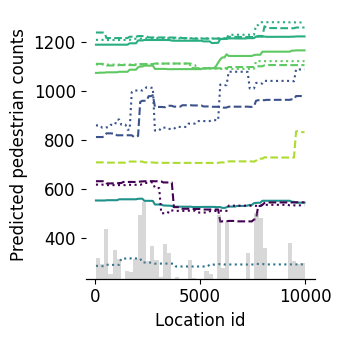

    Dataset     Model  Location id  Predicted Value
0  Mornings  LightGBM    51.000000        709.48211
1  Mornings  LightGBM   151.060606        709.48211
2  Mornings  LightGBM   251.121212        709.48211
3  Mornings  LightGBM   351.181818        709.48211
4  Mornings  LightGBM   451.242424        709.48211


In [157]:
feature_name = "Location id"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+"Location ID_pdp_values.csv"  # Save predictions as CSV
)

print(df_results.head())  # Preview the DataFrame

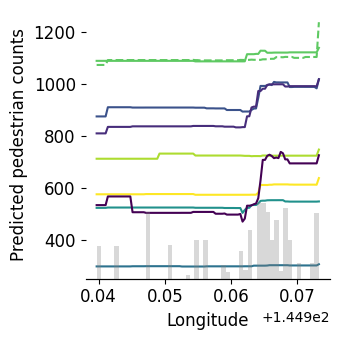

  Dataset     Model   Longitude  Predicted Value
0     All  CatBoost  144.939707       575.420945
1     All  CatBoost  144.940046       575.420945
2     All  CatBoost  144.940384       575.420945
3     All  CatBoost  144.940723       575.420945
4     All  CatBoost  144.941062       575.420945


In [ ]:
feature_name = "Longitude"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

#### Time

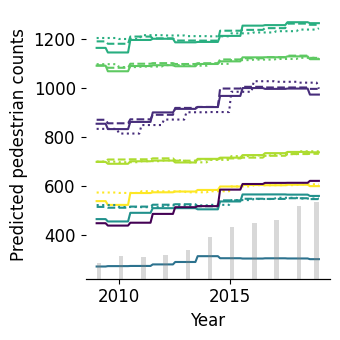

  Dataset     Model        Year  Predicted Value
0     All  CatBoost  2009.00000       539.586374
1     All  CatBoost  2009.10101       539.586374
2     All  CatBoost  2009.20202       539.586374
3     All  CatBoost  2009.30303       539.586374
4     All  CatBoost  2009.40404       539.586374


In [ ]:
feature_name = "Year"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

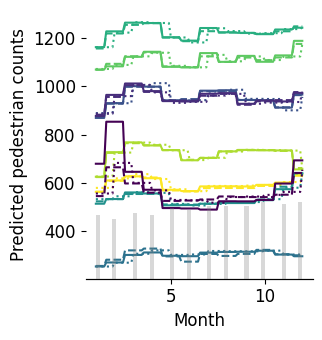

  Dataset     Model     Month  Predicted Value
0     All  CatBoost  1.000000       563.511204
1     All  CatBoost  1.111111       563.511204
2     All  CatBoost  1.222222       563.511204
3     All  CatBoost  1.333333       563.511204
4     All  CatBoost  1.444444       563.511204


In [20]:
feature_name = "Month"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png" #,Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

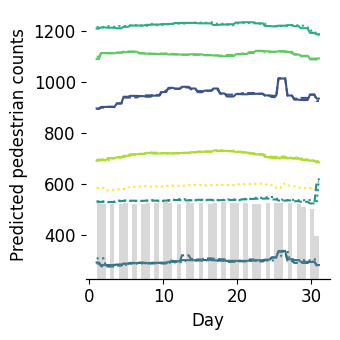

  Dataset    Model       Day  Predicted Value
0     All  XGBoost  1.000000       586.012878
1     All  XGBoost  1.303030       586.012878
2     All  XGBoost  1.606061       586.012878
3     All  XGBoost  1.909091       586.012878
4     All  XGBoost  2.212121       576.644348


In [21]:
feature_name = "Day"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png"#, Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

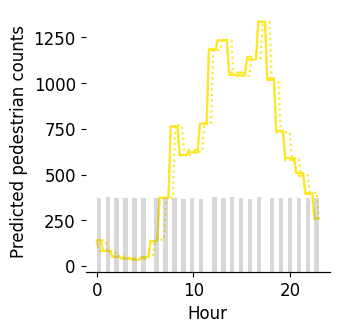

  Dataset     Model      Hour  Predicted Value
0     All  CatBoost  0.000000       140.906300
1     All  CatBoost  0.232323       140.906300
2     All  CatBoost  0.464646       140.906300
3     All  CatBoost  0.696970        81.782267
4     All  CatBoost  0.929293        81.782267


In [22]:
feature_name = "Hour"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

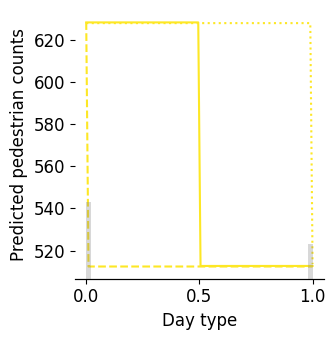

  Dataset     Model  Day type  Predicted Value
0     All  CatBoost  0.000000       628.270735
1     All  CatBoost  0.010101       628.270735
2     All  CatBoost  0.020202       628.270735
3     All  CatBoost  0.030303       628.270735
4     All  CatBoost  0.040404       628.270735


In [23]:
feature_name = "Day type"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

#### Weather

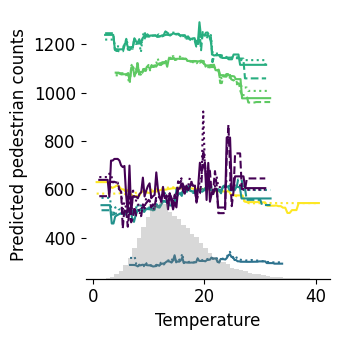

  Dataset     Model  Temperature  Predicted Value
0     All  CatBoost     0.700000       629.521338
1     All  CatBoost     1.103030       629.521338
2     All  CatBoost     1.506061       629.521338
3     All  CatBoost     1.909091       629.521338
4     All  CatBoost     2.312121       629.521338


In [24]:
feature_name = "Temperature"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

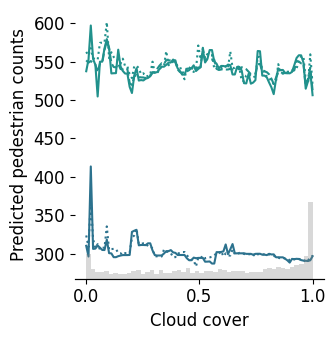

    Dataset     Model  Cloud cover  Predicted Value
0  Evenings  CatBoost     0.000000       537.489967
1  Evenings  CatBoost     0.010101       552.682650
2  Evenings  CatBoost     0.020202       597.043574
3  Evenings  CatBoost     0.030303       553.509944
4  Evenings  CatBoost     0.040404       545.858957


In [25]:
feature_name = "Cloud cover"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

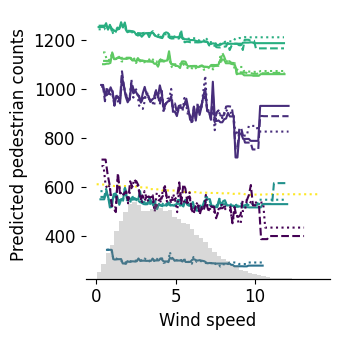

  Dataset    Model  Wind speed  Predicted Value
0     All  XGBoost    0.010000       611.622742
1     All  XGBoost    0.151515       611.622742
2     All  XGBoost    0.293030       609.806396
3     All  XGBoost    0.434545       610.675415
4     All  XGBoost    0.576061       609.635437


In [26]:
feature_name = "Wind speed"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

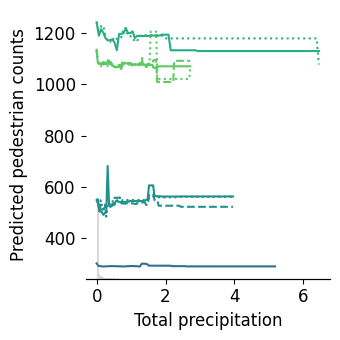

   Dataset     Model  Total precipitation  Predicted Value
0  Lunches  CatBoost             0.000000      1133.926792
1  Lunches  CatBoost             0.027467      1091.473657
2  Lunches  CatBoost             0.054934      1079.733484
3  Lunches  CatBoost             0.082402      1079.646628
4  Lunches  CatBoost             0.109869      1080.346902


In [27]:
feature_name = "Total precipitation"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

#### Population

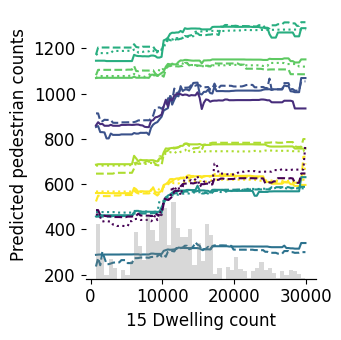

  Dataset     Model  15 Dwelling count  Predicted Value
0     All  CatBoost         757.000000       560.541778
1     All  CatBoost        1052.252525       560.541778
2     All  CatBoost        1347.505051       560.329136
3     All  CatBoost        1642.757576       560.329136
4     All  CatBoost        1938.010101       560.329136


In [28]:
feature_name = "15 Dwelling count"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

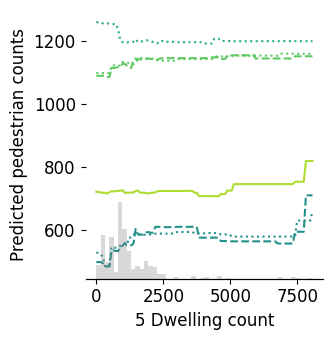

    Dataset     Model  5 Dwelling count  Predicted Value
0  Mornings  CatBoost          0.000000       720.323948
1  Mornings  CatBoost         81.454545       720.015633
2  Mornings  CatBoost        162.909091       717.716609
3  Mornings  CatBoost        244.363636       717.536033
4  Mornings  CatBoost        325.818182       717.536033


In [29]:
feature_name = "5 Dwelling count"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

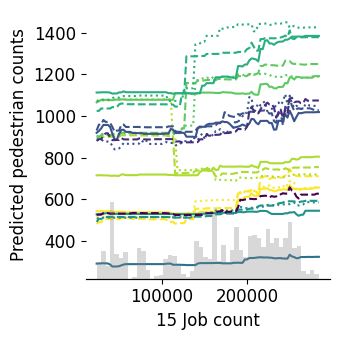

  Dataset     Model  15 Job count  Predicted Value
0     All  CatBoost  23682.000000       542.903460
1     All  CatBoost  26312.050505       542.903460
2     All  CatBoost  28942.101010       544.834712
3     All  CatBoost  31572.151515       543.306260
4     All  CatBoost  34202.202020       543.306260


In [30]:
feature_name = "15 Job count"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

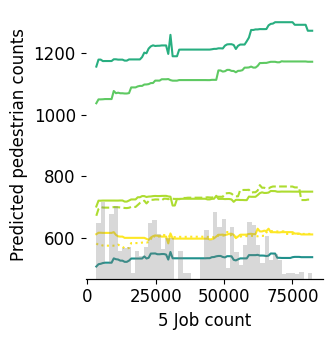

  Dataset     Model  5 Job count  Predicted Value
0     All  CatBoost  3358.000000       611.797607
1     All  CatBoost  4154.414141       616.502370
2     All  CatBoost  4950.828283       616.502370
3     All  CatBoost  5747.242424       616.035474
4     All  CatBoost  6543.656566       616.037129


In [31]:
feature_name = "5 Job count"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

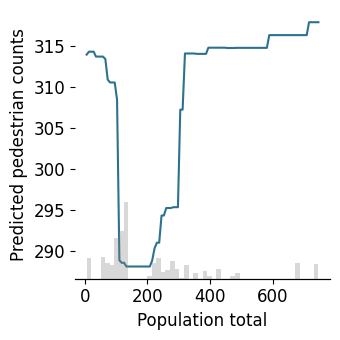

            Dataset     Model  Population total  Predicted Value
0  Mornings Special  CatBoost          6.000000       313.976315
1  Mornings Special  CatBoost         13.464646       314.335159
2  Mornings Special  CatBoost         20.929293       314.335159
3  Mornings Special  CatBoost         28.393939       314.335159
4  Mornings Special  CatBoost         35.858586       313.735261


In [32]:
feature_name = "Population total"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

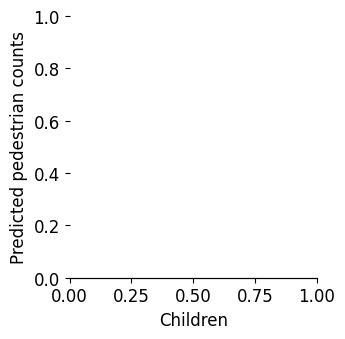

Empty DataFrame
Columns: [Dataset, Model, Children, Predicted Value]
Index: []


In [ ]:
feature_name = "Children"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

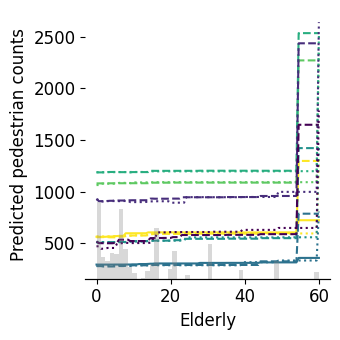

  Dataset     Model   Elderly  Predicted Value
0     All  CatBoost  0.000000       563.869454
1     All  CatBoost  0.606061       563.507972
2     All  CatBoost  1.212121       563.507972
3     All  CatBoost  1.818182       563.507972
4     All  CatBoost  2.424242       563.507972


In [34]:
feature_name = "Elderly"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

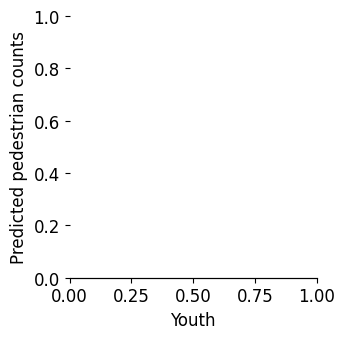

Empty DataFrame
Columns: [Dataset, Model, Youth, Predicted Value]
Index: []


In [35]:
feature_name = "Youth"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

#### Buildings

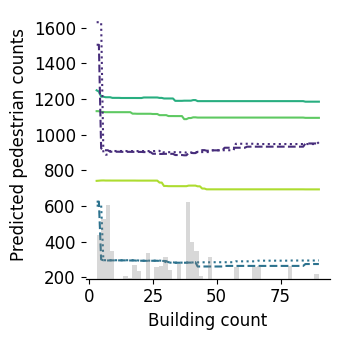

    Dataset     Model  Building count  Predicted Value
0  Mornings  CatBoost        3.000000       740.993797
1  Mornings  CatBoost        3.878788       741.971680
2  Mornings  CatBoost        4.757576       742.982695
3  Mornings  CatBoost        5.636364       743.312546
4  Mornings  CatBoost        6.515152       742.706973


In [36]:
feature_name = "Building count"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

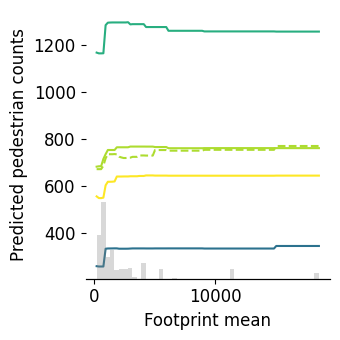

  Dataset     Model  Footprint mean  Predicted Value
0     All  CatBoost      205.878000       555.510513
1     All  CatBoost      391.307283       548.330829
2     All  CatBoost      576.736566       548.182899
3     All  CatBoost      762.165848       550.195489
4     All  CatBoost      947.595131       602.634927


In [37]:
feature_name = "Footprint mean"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

#### Street nework

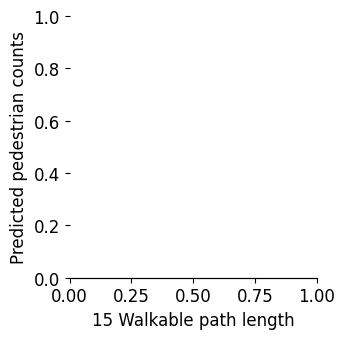

Empty DataFrame
Columns: [Dataset, Model, 15 Walkable path length, Predicted Value]
Index: []


In [38]:
feature_name = "15 Walkable path length"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

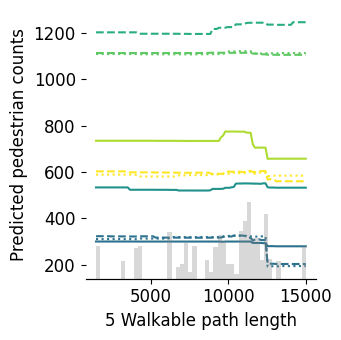

  Dataset     Model  5 Walkable path length  Predicted Value
0     All  LightGBM             1423.160000       602.935487
1     All  LightGBM             1560.427677       602.935487
2     All  LightGBM             1697.695354       602.935487
3     All  LightGBM             1834.963030       602.935487
4     All  LightGBM             1972.230707       602.935487


In [39]:
feature_name = "5 Walkable path length"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

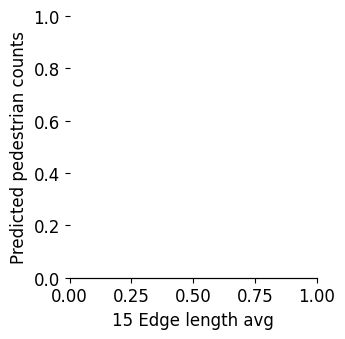

Empty DataFrame
Columns: [Dataset, Model, 15 Edge length avg, Predicted Value]
Index: []


In [40]:
feature_name = "15 Edge length avg"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

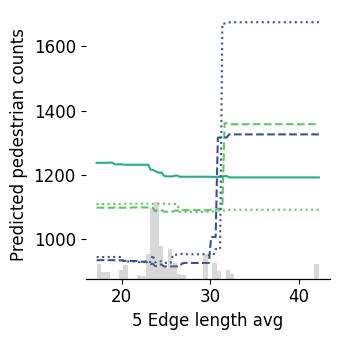

   Dataset     Model  5 Edge length avg  Predicted Value
0  Lunches  LightGBM          17.186690      1098.001243
1  Lunches  LightGBM          17.439928      1098.001243
2  Lunches  LightGBM          17.693165      1098.001243
3  Lunches  LightGBM          17.946402      1098.001243
4  Lunches  LightGBM          18.199639      1098.001243


In [41]:
feature_name = "5 Edge length avg"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

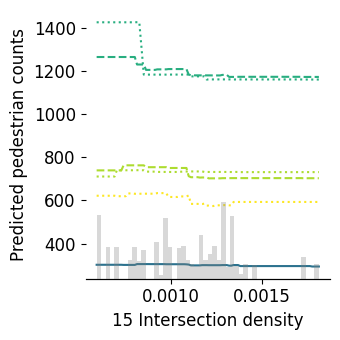

  Dataset    Model  15 Intersection density  Predicted Value
0     All  XGBoost                 0.000590       621.776794
1     All  XGBoost                 0.000603       621.776794
2     All  XGBoost                 0.000615       621.776794
3     All  XGBoost                 0.000627       621.776794
4     All  XGBoost                 0.000640       621.776794


In [42]:
feature_name = "15 Intersection density"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

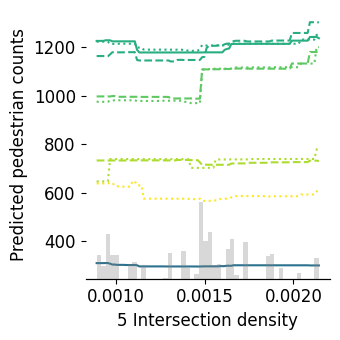

  Dataset    Model  5 Intersection density  Predicted Value
0     All  XGBoost                0.000893       638.418762
1     All  XGBoost                0.000906       638.418762
2     All  XGBoost                0.000918       638.418762
3     All  XGBoost                0.000931       638.418762
4     All  XGBoost                0.000943       638.418762


In [43]:
feature_name = "5 Intersection density"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

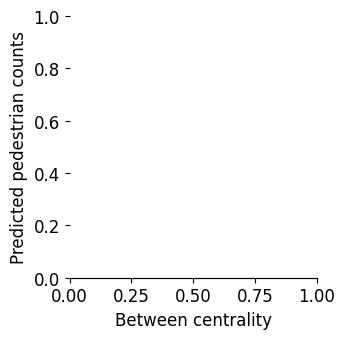

Empty DataFrame
Columns: [Dataset, Model, Between centrality, Predicted Value]
Index: []


In [44]:
feature_name = "Between centrality"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

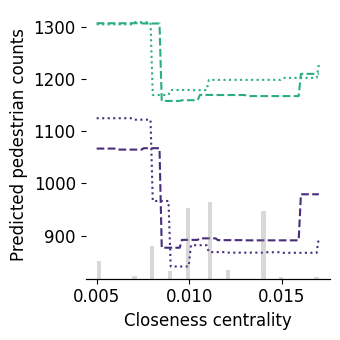

      Dataset     Model  Closeness centrality  Predicted Value
0  Afternoons  LightGBM              0.005000      1306.837546
1  Afternoons  LightGBM              0.005121      1306.837546
2  Afternoons  LightGBM              0.005242      1306.837546
3  Afternoons  LightGBM              0.005364      1306.837546
4  Afternoons  LightGBM              0.005485      1306.837546


In [45]:
feature_name = "Closeness centrality"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

#### Public transport

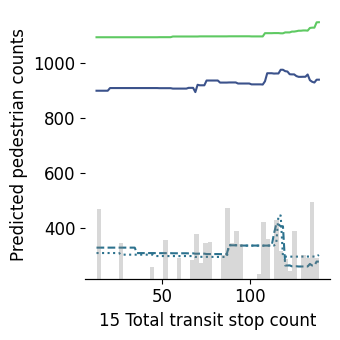

   Dataset     Model  15 Total transit stop count  Predicted Value
0  Lunches  CatBoost                    13.000000      1094.115338
1  Lunches  CatBoost                    14.272727      1094.115338
2  Lunches  CatBoost                    15.545455      1094.115338
3  Lunches  CatBoost                    16.818182      1094.115338
4  Lunches  CatBoost                    18.090909      1094.115338


In [46]:
feature_name = "15 Total transit stop count"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

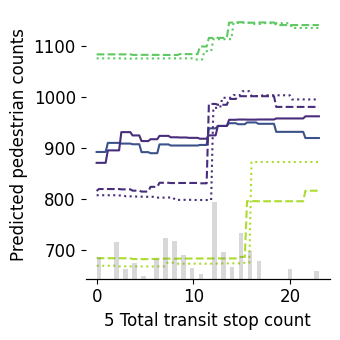

    Dataset     Model  5 Total transit stop count  Predicted Value
0  Mornings  LightGBM                    0.000000       684.799790
1  Mornings  LightGBM                    0.232323       684.539542
2  Mornings  LightGBM                    0.464646       684.539542
3  Mornings  LightGBM                    0.696970       684.539542
4  Mornings  LightGBM                    0.929293       684.539542


In [47]:
feature_name = "5 Total transit stop count"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

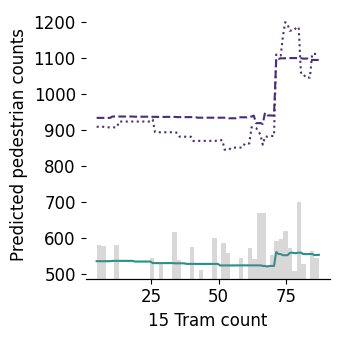

    Dataset     Model  15 Tram count  Predicted Value
0  Evenings  CatBoost       5.000000       536.779049
1  Evenings  CatBoost       5.828283       536.779049
2  Evenings  CatBoost       6.656566       536.779049
3  Evenings  CatBoost       7.484848       536.779049
4  Evenings  CatBoost       8.313131       536.779049


In [48]:
feature_name = "15 Tram count"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

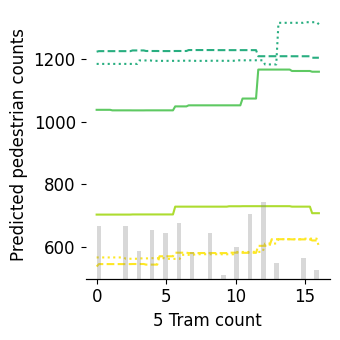

  Dataset     Model  5 Tram count  Predicted Value
0     All  LightGBM      0.000000       535.972789
1     All  LightGBM      0.161616       543.715001
2     All  LightGBM      0.323232       543.715001
3     All  LightGBM      0.484848       543.715001
4     All  LightGBM      0.646465       543.715001


In [49]:
feature_name = "5 Tram count"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

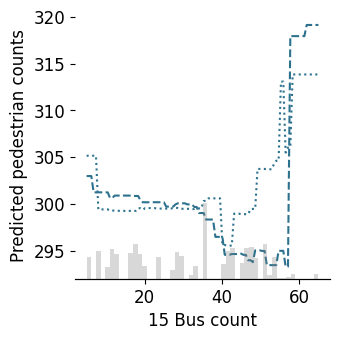

            Dataset     Model  15 Bus count  Predicted Value
0  Mornings Special  LightGBM      5.000000       302.987872
1  Mornings Special  LightGBM      5.606061       302.987872
2  Mornings Special  LightGBM      6.212121       302.987872
3  Mornings Special  LightGBM      6.818182       301.245346
4  Mornings Special  LightGBM      7.424242       301.245346


In [50]:
feature_name = "15 Bus count"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

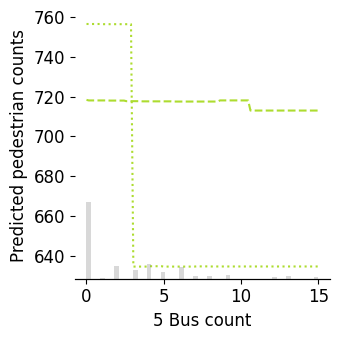

    Dataset     Model  5 Bus count  Predicted Value
0  Mornings  LightGBM     0.000000       718.322309
1  Mornings  LightGBM     0.151515       718.046373
2  Mornings  LightGBM     0.303030       718.046373
3  Mornings  LightGBM     0.454545       718.046373
4  Mornings  LightGBM     0.606061       718.046373


In [51]:
feature_name = "5 Bus count"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

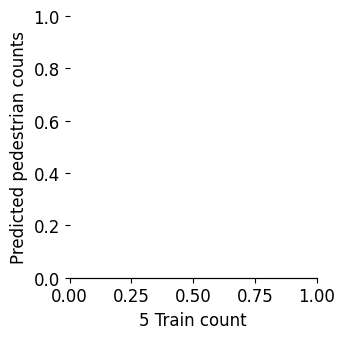

Empty DataFrame
Columns: [Dataset, Model, 5 Train count, Predicted Value]
Index: []


In [52]:
feature_name = "5 Train count"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

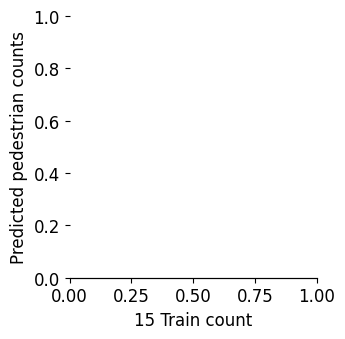

Empty DataFrame
Columns: [Dataset, Model, 15 Train count, Predicted Value]
Index: []


In [53]:
feature_name = "15 Train count"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

#### Infrastructure

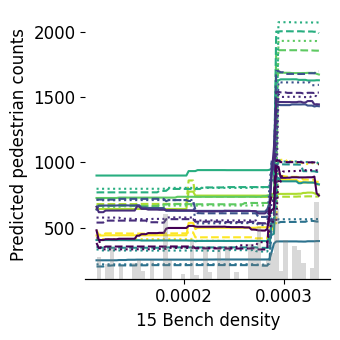

  Dataset     Model  15 Bench density  Predicted Value
0     All  CatBoost          0.000113       438.590378
1     All  CatBoost          0.000115       438.590378
2     All  CatBoost          0.000117       438.590378
3     All  CatBoost          0.000119       438.590378
4     All  CatBoost          0.000122       440.605786


In [54]:
feature_name = "15 Bench density"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

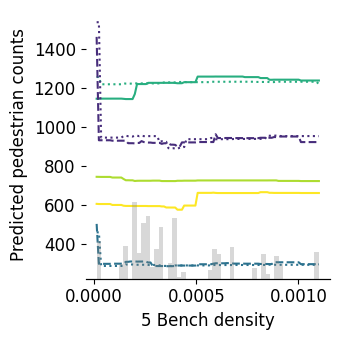

  Dataset     Model  5 Bench density  Predicted Value
0     All  CatBoost         0.000012       607.349413
1     All  CatBoost         0.000023       606.544753
2     All  CatBoost         0.000034       606.544753
3     All  CatBoost         0.000045       606.544753
4     All  CatBoost         0.000056       606.544753


In [55]:
feature_name = "5 Bench density"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

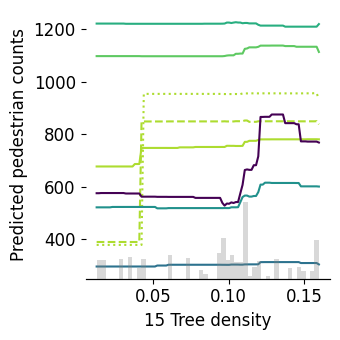

    Dataset     Model  15 Tree density  Predicted Value
0  Mornings  CatBoost         0.012903       677.058912
1  Mornings  CatBoost         0.014385       677.058912
2  Mornings  CatBoost         0.015867       677.058912
3  Mornings  CatBoost         0.017349       677.058912
4  Mornings  CatBoost         0.018831       677.058912


In [56]:
feature_name = "15 Tree density"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

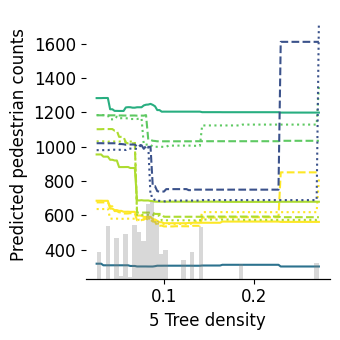

  Dataset     Model  5 Tree density  Predicted Value
0     All  CatBoost        0.025144       685.763688
1     All  CatBoost        0.027642       685.763688
2     All  CatBoost        0.030140       685.763688
3     All  CatBoost        0.032637       685.344986
4     All  CatBoost        0.035135       685.344986


In [57]:
feature_name = "5 Tree density"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

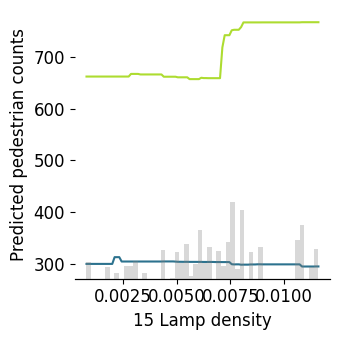

    Dataset     Model  15 Lamp density  Predicted Value
0  Mornings  CatBoost         0.000811       661.727183
1  Mornings  CatBoost         0.000920       661.727183
2  Mornings  CatBoost         0.001029       661.727183
3  Mornings  CatBoost         0.001138       661.727183
4  Mornings  CatBoost         0.001246       661.727183


In [58]:
feature_name = "15 Lamp density"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

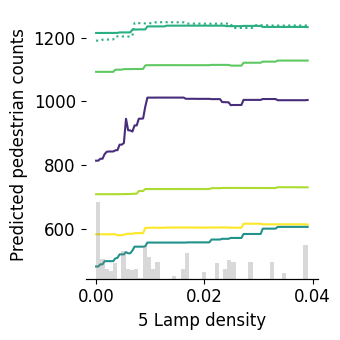

  Dataset     Model  5 Lamp density  Predicted Value
0     All  CatBoost        0.000000       581.845752
1     All  CatBoost        0.000395       581.845752
2     All  CatBoost        0.000790       581.845752
3     All  CatBoost        0.001185       581.845752
4     All  CatBoost        0.001579       581.845752


In [59]:
feature_name = "5 Lamp density"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

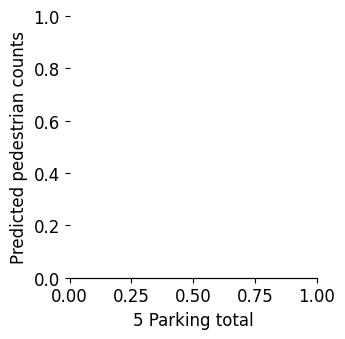

Empty DataFrame
Columns: [Dataset, Model, 5 Parking total, Predicted Value]
Index: []


In [60]:
feature_name = "5 Parking total"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

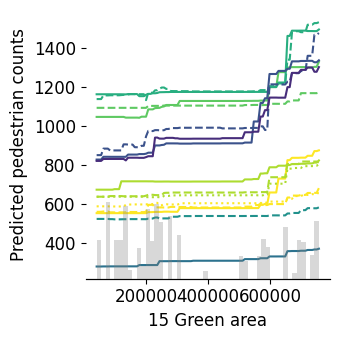

  Dataset     Model  15 Green area  Predicted Value
0     All  CatBoost   41566.400000       553.525849
1     All  CatBoost   48785.100909       553.525849
2     All  CatBoost   56003.801818       553.525849
3     All  CatBoost   63222.502727       553.525849
4     All  CatBoost   70441.203636       553.525849


In [61]:
feature_name = "15 Green area"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

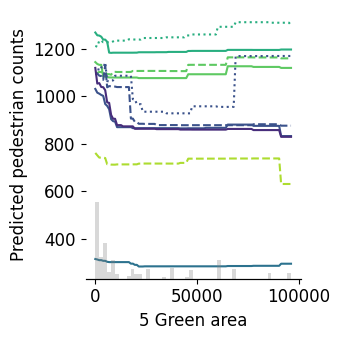

    Dataset     Model  5 Green area  Predicted Value
0  Mornings  LightGBM      0.000000       761.636410
1  Mornings  LightGBM    970.871313       751.439969
2  Mornings  LightGBM   1941.742626       741.805009
3  Mornings  LightGBM   2912.613939       741.880651
4  Mornings  LightGBM   3883.485253       741.868548


In [62]:
feature_name = "5 Green area"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

#### Urban use diversity

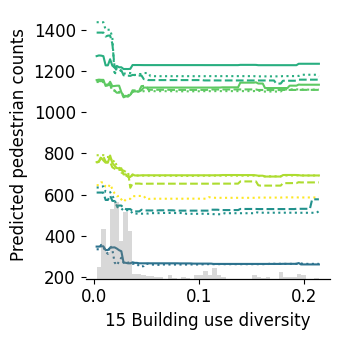

  Dataset    Model  15 Building use diversity  Predicted Value
0     All  XGBoost                   0.002379       645.696838
1     All  XGBoost                   0.004520       645.696838
2     All  XGBoost                   0.006661       659.423462
3     All  XGBoost                   0.008802       658.267822
4     All  XGBoost                   0.010943       638.178101


In [63]:
feature_name = "15 Building use diversity"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

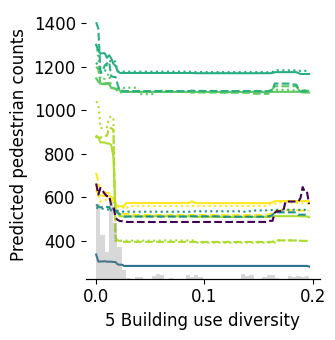

  Dataset     Model  5 Building use diversity  Predicted Value
0     All  CatBoost                  0.000000       659.913508
1     All  CatBoost                  0.001987       608.190307
2     All  CatBoost                  0.003974       606.706080
3     All  CatBoost                  0.005961       607.791201
4     All  CatBoost                  0.007947       604.790847


In [64]:
feature_name = "5 Building use diversity"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

#### Visual index

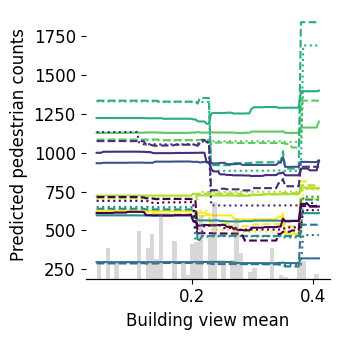

  Dataset     Model  Building view mean  Predicted Value
0     All  CatBoost            0.043000       623.142130
1     All  CatBoost            0.046711       623.142130
2     All  CatBoost            0.050422       623.142130
3     All  CatBoost            0.054133       626.716329
4     All  CatBoost            0.057845       626.716329


In [65]:
feature_name = "Building view mean"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

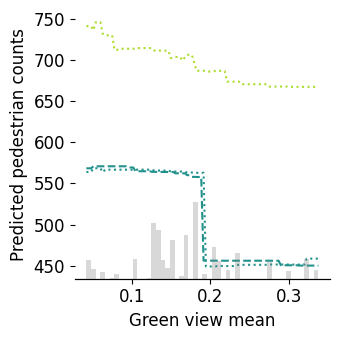

    Dataset    Model  Green view mean  Predicted Value
0  Mornings  XGBoost          0.04200       740.860962
1  Mornings  XGBoost          0.04499       740.860962
2  Mornings  XGBoost          0.04798       740.860962
3  Mornings  XGBoost          0.05097       735.894287
4  Mornings  XGBoost          0.05396       745.577576


In [66]:
feature_name = "Green view mean"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

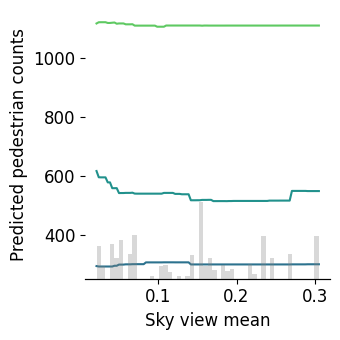

   Dataset     Model  Sky view mean  Predicted Value
0  Lunches  CatBoost       0.021000      1115.183216
1  Lunches  CatBoost       0.023872      1119.256738
2  Lunches  CatBoost       0.026744      1119.372640
3  Lunches  CatBoost       0.029616      1119.372640
4  Lunches  CatBoost       0.032488      1119.372640


In [67]:
feature_name = "Sky view mean"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png",  # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

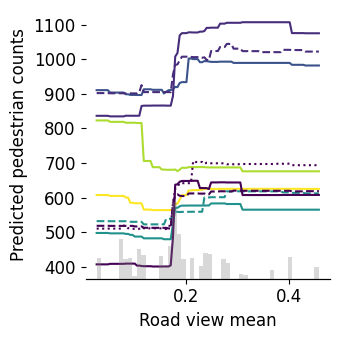

  Dataset     Model  Road view mean  Predicted Value
0     All  CatBoost        0.027667       607.718452
1     All  CatBoost        0.032003       607.718452
2     All  CatBoost        0.036340       607.718452
3     All  CatBoost        0.040677       607.718452
4     All  CatBoost        0.045013       607.718452


In [68]:
feature_name = "Road view mean"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png", # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

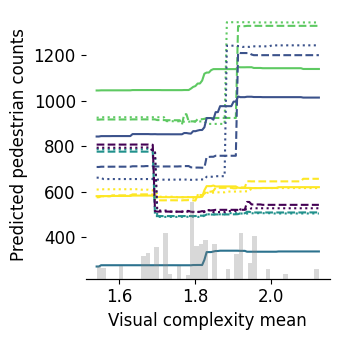

  Dataset     Model  Visual complexity mean  Predicted Value
0     All  CatBoost                1.540997       579.833819
1     All  CatBoost                1.546914       579.833819
2     All  CatBoost                1.552831       580.039659
3     All  CatBoost                1.558748       580.039659
4     All  CatBoost                1.564664       580.039659


In [69]:
feature_name = "Visual complexity mean"
df_results = pdp_combined_with_histogram(
    feature_name=feature_name,datasets=datasets, 
    # save_path=output_dir+"/"+f"{feature_name}.png", # Save the plot
    save_csv=output_dir+"/"+f"{feature_name}_pdp_values.csv"  # Save predictions as CSV
)
print(df_results.head())  # Preview the DataFrame

In [17]:
def plot_pdp_with_histogram_from_csv_and_data(feature_name, csv_path,
                                            nbin=50, instH=0.3, instAlpha=0.3, font_size=12, figSize=(3.5, 3.5), save_path=None):
    # Load the CSV data for predictions
    df = pd.read_csv(csv_path)
    
    # Get unique datasets from the CSV
    datasets = df['Dataset'].unique()

    # Create figure and axis for PDP plot
    fig, ax1 = plt.subplots(figsize=figSize)
    ax2 = ax1.twinx()  # Secondary axis for the histogram

    # Define colors for datasets and line styles for models
    dataset_colors = plt.cm.viridis(np.linspace(0, 1, len(datasets)))[::-1]  # One color per dataset
    model_styles = {"CatBoost": "-", "LightGBM": "--", "XGBoost": ":"}  # Different line styles for models
    
    # Plot PDP curves based on CSV predictions
    for idx, dataset in enumerate(datasets):
        color = dataset_colors[idx]
        
        # Filter data for the current dataset
        df_dataset = df[df['Dataset'] == dataset]
        
        # Plot predictions from CSV for each model (CatBoost, LightGBM, XGBoost)
        for model in ['CatBoost', 'LightGBM', 'XGBoost']:
            model_data = df_dataset[df_dataset['Model'] == model]
            ax1.plot(model_data[feature_name], model_data['Predicted Value'], model_styles[model], color=color, label=f"{dataset} - {model}")

    # Plot histogram using processed_melbourne_data
    ax2.hist(processed_melbourne_data[feature_name], bins=nbin, color="gray", alpha=instAlpha, density=True, label="Instances")
    
    # Scale down histogram heights
    for patch in ax2.patches:
        patch.set_height(patch.get_height() * instH)

    # Customize plot appearance
    ax1.set_xlabel(feature_name, fontsize=font_size)
    ax1.set_ylabel("Predicted Value", fontsize=font_size)
    ax2.set_ylabel("")  
    ax2.set_yticks([])  

    # Add legend
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2 = [ax2.patches[0]]  # Use the first bar in the histogram as a legend entry
    labels2 = ["Instances"]
    # ax1.legend(handles1 + handles2, labels1 + labels2, fontsize=font_size, loc="upper left", bbox_to_anchor=(1, 1))

    # Hide unnecessary spines
    for spine in ax1.spines.values():
        if spine != ax1.spines["bottom"]:
            spine.set_visible(False)
    for spine in ax2.spines.values():
        if spine != ax2.spines["bottom"]:
            spine.set_visible(False)

    plt.tight_layout()

    # Save the plot if save_path is specified
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
    plt.show()

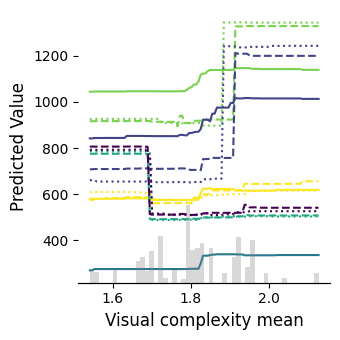

In [19]:
feature_name = "Visual complexity mean"
csv_path = output_dir + f"/{feature_name}_pdp_values.csv"

# Call the function to plot PDP and histogram
plot_pdp_with_histogram_from_csv_and_data(
    feature_name=feature_name,
    csv_path=csv_path,
    nbin=50,
    instH=0.3,
    instAlpha=0.3
)

In [18]:
processed_melbourne_data_renamed = processed_melbourne_data.copy()
processed_melbourne_data_renamed.columns = processed_melbourne_data_renamed.columns.str.replace("_", " ")

In [19]:
def modified_plot_pdp_with_histogram_from_csv_and_data(feature_name, csv_path, dataset_names,
                                              processed_data = processed_melbourne_data_renamed, 
                                              nbin=50, instH=0.3, instAlpha=0.3, ax=None):
    # Read predictions from CSV
    df_plot = pd.read_csv(csv_path)
    
    # Check if ax is provided, otherwise create one
    if ax is None:
        fig, ax1 = plt.subplots(figsize=(3.5, 3.5))
    else:
        ax1 = ax
    
    ax2 = ax1.twinx()  # Secondary axis for histogram
    
    # Define model styles (same across datasets)
    model_styles = {"CatBoost": "-", "LightGBM": "--", "XGBoost": ":"}
    
    # Assign unique colors per dataset
    dataset_colors = plt.cm.viridis(np.linspace(0, 1, len(dataset_names)))[::-1]  # Reverse to match original function
    dataset_color_map = dict(zip(dataset_names, dataset_colors))  # Map dataset names to colors
    
    # Plot predictions
    for dataset in dataset_names:
        color = dataset_color_map.get(dataset, "black")  # Ensure color consistency per dataset
        for model, style in model_styles.items():
            df_model = df_plot[(df_plot["Dataset"] == dataset) & (df_plot["Model"] == model)]
            if not df_model.empty:
                ax1.plot(df_model[feature_name], df_model["Predicted Value"], style, color=color)

    # Plot histogram from processed_melbourne_data
    counts, bins, patches = ax2.hist(
        processed_data[feature_name],
        bins=nbin,
        color="gray",
        alpha=instAlpha,
        density=True,
    )

    # Scale down histogram heights
    for patch in patches:
        patch.set_height(patch.get_height() * instH)

    # Formatting: Remove y-axis ticks for histogram, remove legend
    ax1.set_ylabel("Predicted pedestrian counts", fontsize=12)
    ax2.set_yticks([])  # Remove ticks from secondary axis
    # In your plotting function, ensure xlim is set appropriately
    ax1.set_xlim(processed_data[feature_name].min(), 
                 processed_data[feature_name].max())
    if feature_name == 'Location id':
        feature_name = 'Locaiton ID'
    ax1.set_xlabel(feature_name, fontsize=12)

    # Hide unnecessary spines
    for spine in ax1.spines.values():
        if spine != ax1.spines["bottom"]:
            spine.set_visible(False)
    for spine in ax2.spines.values():
        if spine != ax2.spines["bottom"]:
            spine.set_visible(False)

    ax1.tick_params(axis="both", labelsize=10)
    
    return ax1


In [20]:
def create_legend_only(ax, dataset_colors, plot_names, model_styles):
    # Create handles and labels for datasets (colors)
    dataset_handles = [
        plt.Line2D([0], [0], color=color, lw=4, label=name)
        for color, name in zip(dataset_colors, plot_names)
    ]
    
    # Create handles and labels for models (line styles, all in gray)
    model_handles = [
        plt.Line2D([0], [0], color="gray", linestyle=style, lw=2, label=model_name)
        for style, model_name in zip(model_styles, ["CatBoost", "LightGBM", "XGBoost"])
    ]
    
    # Create a handle for the histogram (Instances)
    instance_handle = plt.Line2D(
        [0], [0], color="gray", alpha=0.2, lw=10, label="Instances"
    )
    
    # Combine all handles
    all_handles = dataset_handles + model_handles + [instance_handle]
    
    # Add legend to the given axis
    ax.legend(
        handles=all_handles,
        fontsize=12,
        loc="center",
        frameon=False,
        ncol=1,
    )
    
    ax.axis("off")  # Hide axes so only the legend is visible


In [21]:
feature_categories = {
    "Sensor": ["Location id","Longitude"],  # Removed "Location ID", "Latitude"
    "Time": ["Year", "Month", "Day", "Hour","Day type"],
    "Weather": ["Temperature", "Wind speed", "Total precipitation","Cloud cover"],
    "Population": ["5 Dwelling count", "15 Dwelling count", "5 Job count", "15 Job count",#],
                    "Population total", "Elderly"],# ,"Children", "Youth",
    "Urban use diversity":["15 Building use diversity","5 Building use diversity"],
    "Buildings":["Building count","Footprint mean"],
    "Street network":[ "5 Walkable path length", #"15 Walkable path length",
                        "5 Edge length avg","5 Intersection density","15 Intersection density","Closeness centrality"],#"15 Edge length avg","Between centrality",
    "Public transport":["5 Total transit stop count","15 Total transit stop count",
                        "5 Bus count","15 Bus count", "5 Tram count","15 Tram count"],#,"15 Train count","5 Train count"
    "Infrastructure":["5 Bench density","15 Bench density","5 Tree density","15 Tree density",
                      "5 Lamp density","15 Lamp density","5 Green area","15 Green area"],#,"5 Parking total"
    "Visual index": ["Building view mean","Green view mean","Sky view mean","Road view mean","Visual complexity mean"]
}
plot_names = ['All', 'Workday: Mornings', 'Workday: Lunches', 'Workday: Afternoons', 'Workday: Evenings',
                   'Non-workday: Mornings', 'Non-workday: Lunches', 'Non-workday: Afternoons', 'Non-workday: Evenings']

In [22]:
dataset_colors = plt.cm.viridis(np.linspace(0, 1, len(split_df_names)))[::-1]  # One color per dataset
model_styles = ["-", "--", ":"]  # Different line styles for CatBoost, LightGBM, XGBoost
# List of dataset names (used for color consistency)

def plot_pdps_with_histogram_from_csv_and_data(selected_features=feature_categories, legend_location=0, legend_row = 2):
    max_cols = max(len(features) for features in selected_features.values()) + legend_location
    num_rows = len(selected_features)

    fig, axes = plt.subplots(num_rows, max_cols, figsize=(3 * max_cols, 3.5 * num_rows))

    # Ensure axes is always a 2D NumPy array
    axes = np.atleast_2d(axes)  # Converts 1D array/list into a 2D array

    custom_ticks = {
        "Day type": [0, 1],
        "15 Intersection density": [0.001, 0.0015],
        "Closeness centrality": [0.005, 0.010, 0.015],
        "5 Bench density": [0, 0.0005, 0.0010],
        "15 Bench density": [0.00015, 0.0003],
    }

    tp = pd.read_csv(f"{output_dir}/Total precipitation_pdp_values.csv")
    tp_max = tp['Total precipitation'].max()

    for row_idx, (category, features) in enumerate(selected_features.items()):
        for col_idx, feature_name in enumerate(features):
            ax = axes[row_idx, col_idx]  # Now works correctly in all cases

            csv_path = f"{output_dir}/{feature_name}_pdp_values.csv"

            if feature_name == "Total precipitation":
                processed_mel_tp = processed_melbourne_data_renamed[processed_melbourne_data_renamed['Total precipitation'] <= tp_max]
                modified_plot_pdp_with_histogram_from_csv_and_data(
                    feature_name=feature_name, csv_path=csv_path, dataset_names=split_df_names,
                    processed_data=processed_mel_tp, nbin=50, instH=0.2, instAlpha=0.3, ax=ax
                )
            else:
                modified_plot_pdp_with_histogram_from_csv_and_data(
                    feature_name=feature_name, csv_path=csv_path, dataset_names=split_df_names,
                    processed_data=processed_melbourne_data_renamed, nbin=50, instH=0.2, instAlpha=0.3, ax=ax
                )

            if col_idx > 0:
                ax.set_ylabel("")

            if feature_name in custom_ticks:
                ax.set_xticks(custom_ticks[feature_name])

        for col_idx in range(len(features), max_cols):
            fig.delaxes(axes[row_idx, col_idx])

    plt.subplots_adjust(hspace=0.3, wspace=0)

    legend_col = max_cols - 1
    legend_ax = fig.add_subplot(num_rows, max_cols, legend_row * max_cols + legend_col + 1)
    create_legend_only(legend_ax, dataset_colors, plot_names, model_styles)

    plt.tight_layout(pad=0, w_pad=0, h_pad=0.5)
    plt.show()

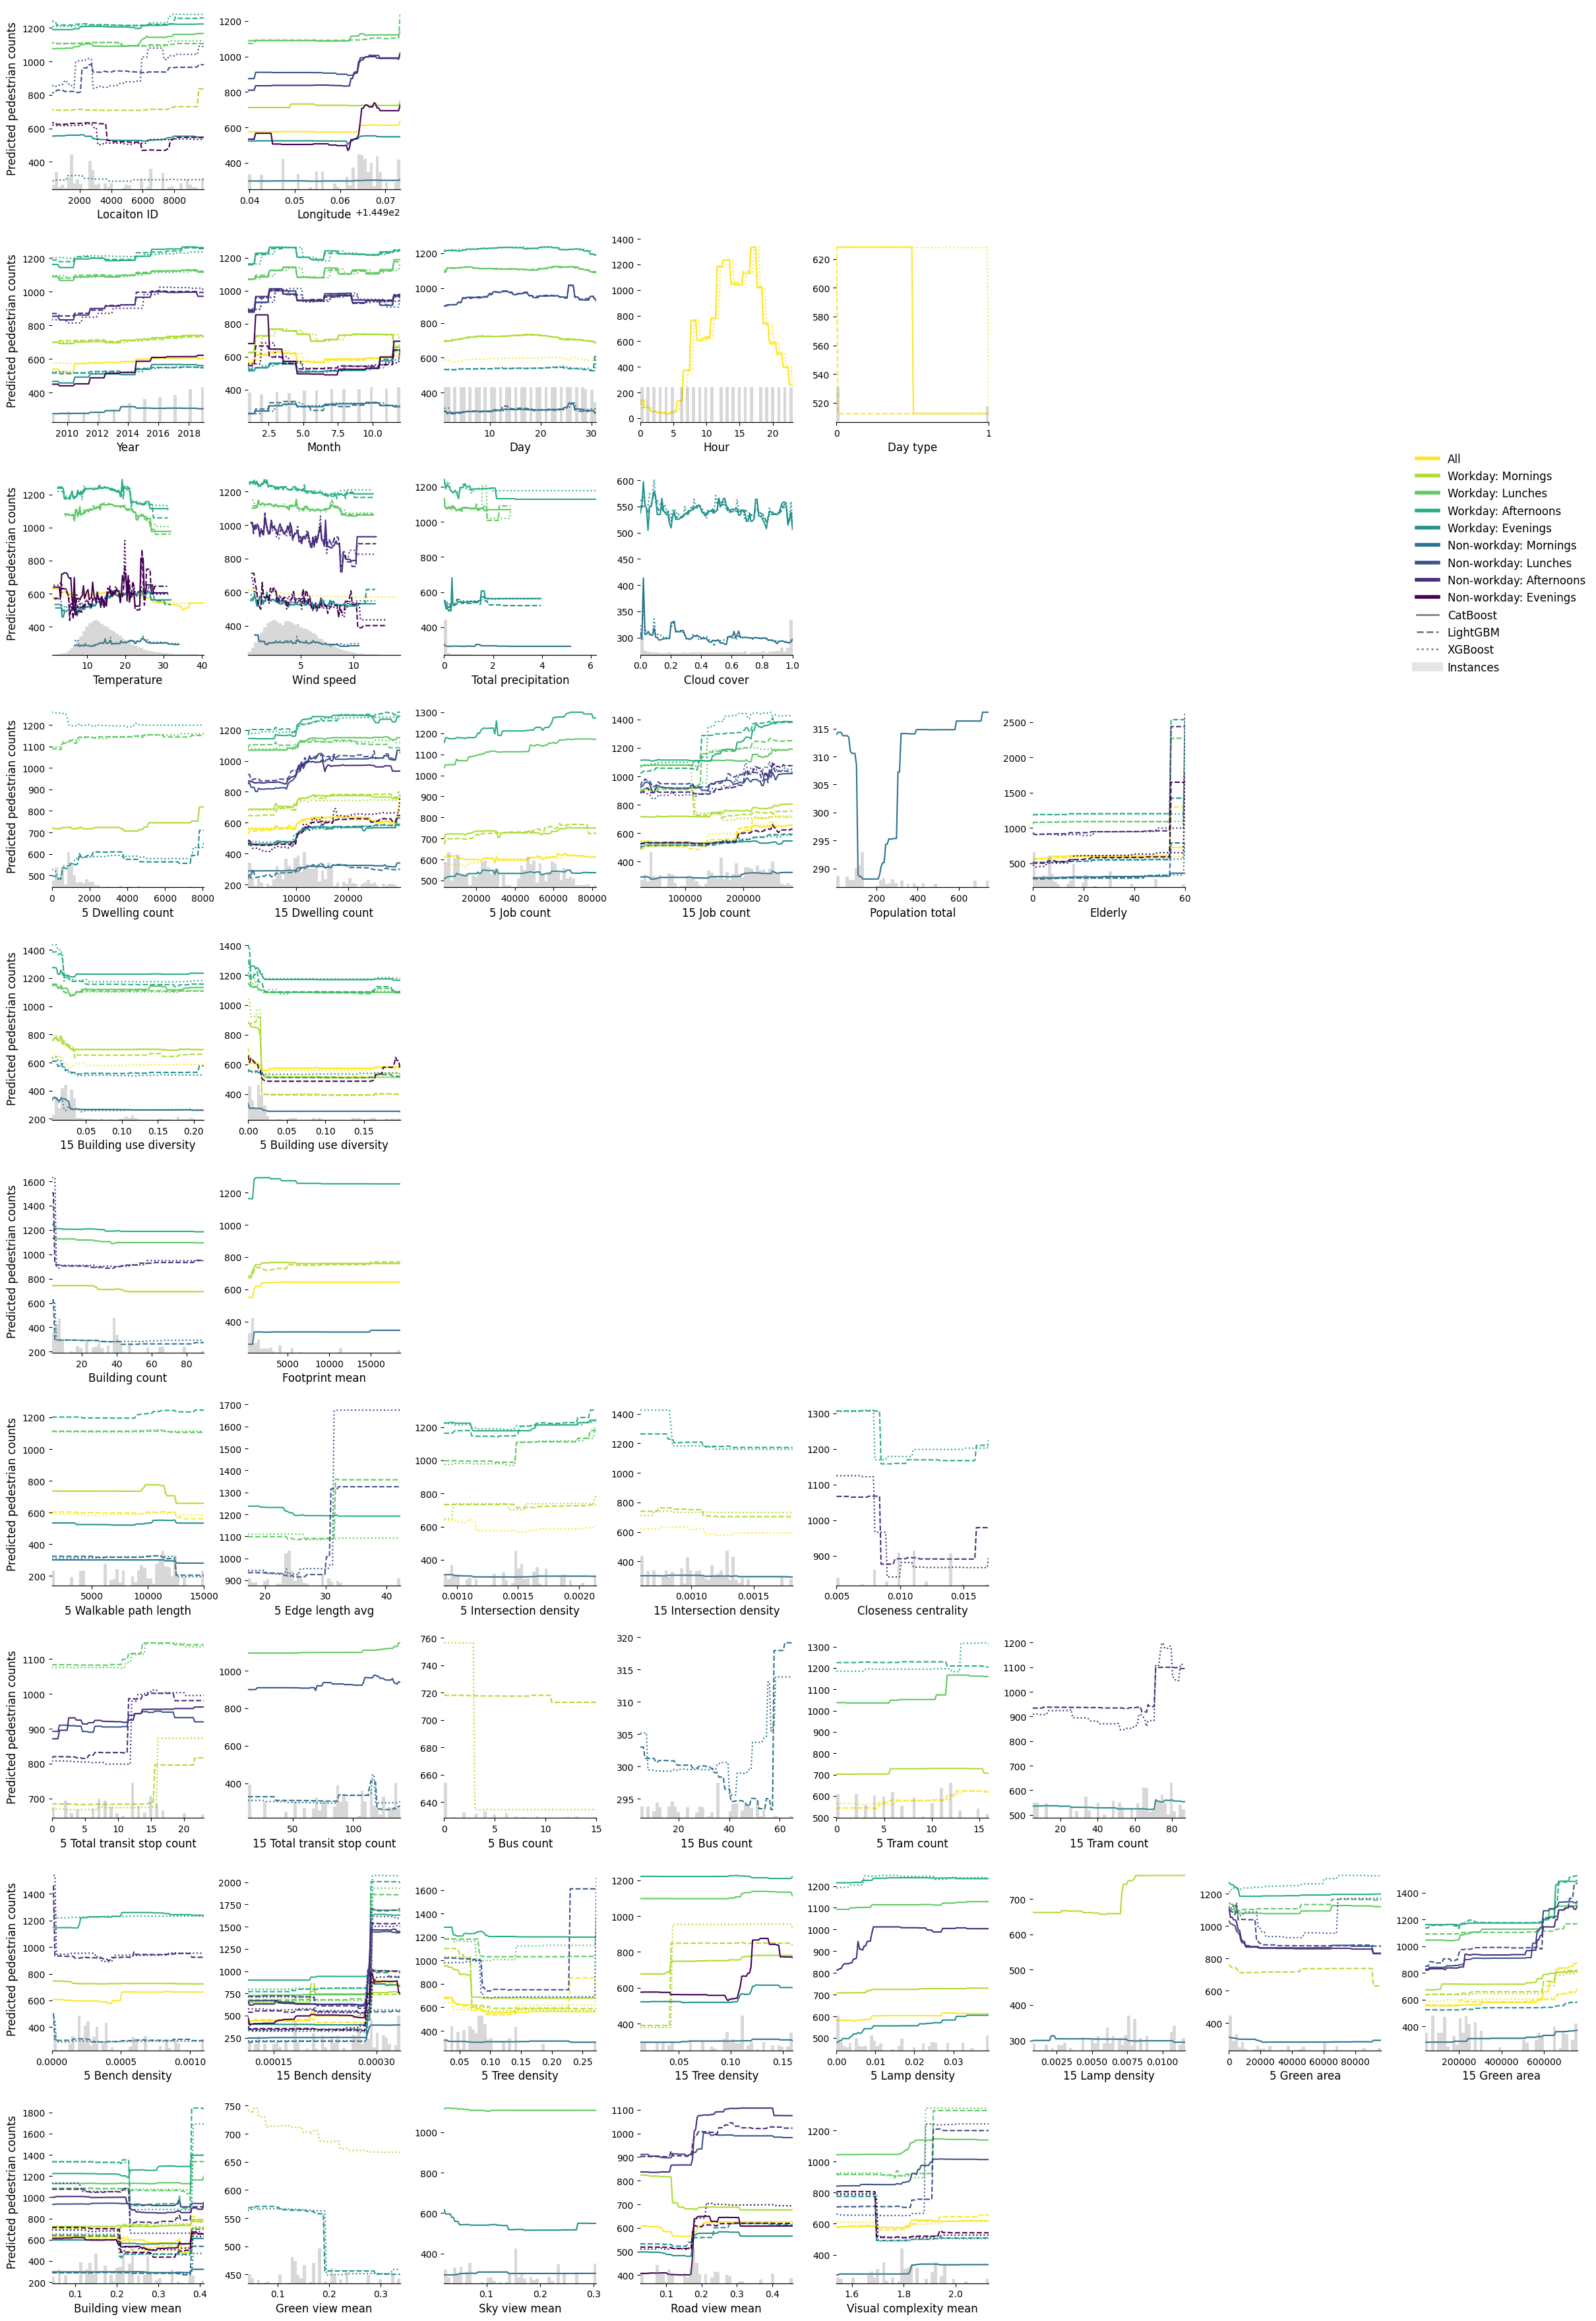

In [184]:
plot_pdps_with_histogram_from_csv_and_data(selected_features = feature_categories, legend_location =0, legend_row =2)

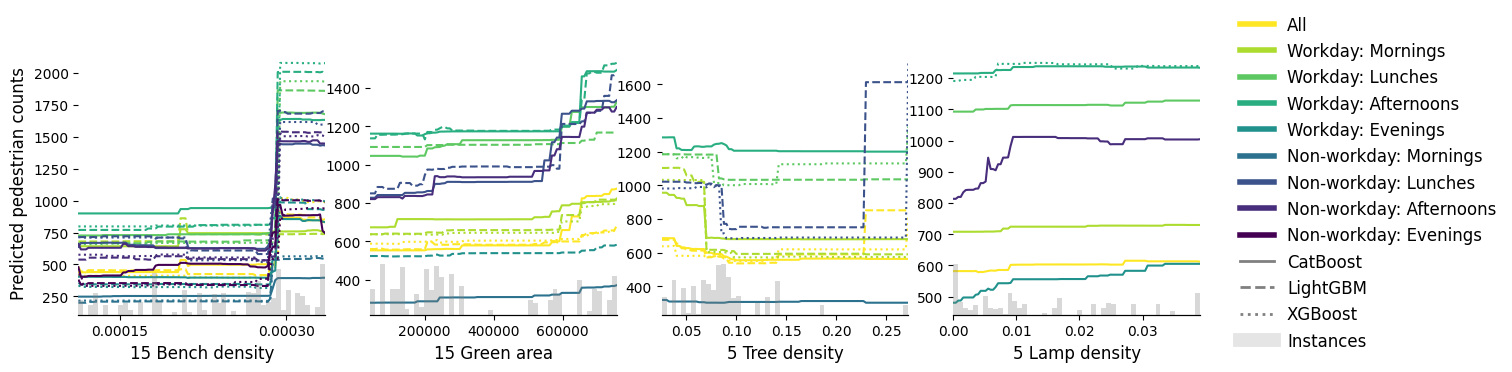

In [27]:
Infra = {"":["15 Bench density","15 Green area","5 Tree density", #"5 Bench density",
                      "5 Lamp density"],#,"5 Parking total", "15 Lamp density"
        # "":["15 Tree density","5 Green area"]
        }
plot_pdps_with_histogram_from_csv_and_data(selected_features = Infra, legend_location =1, legend_row =0)

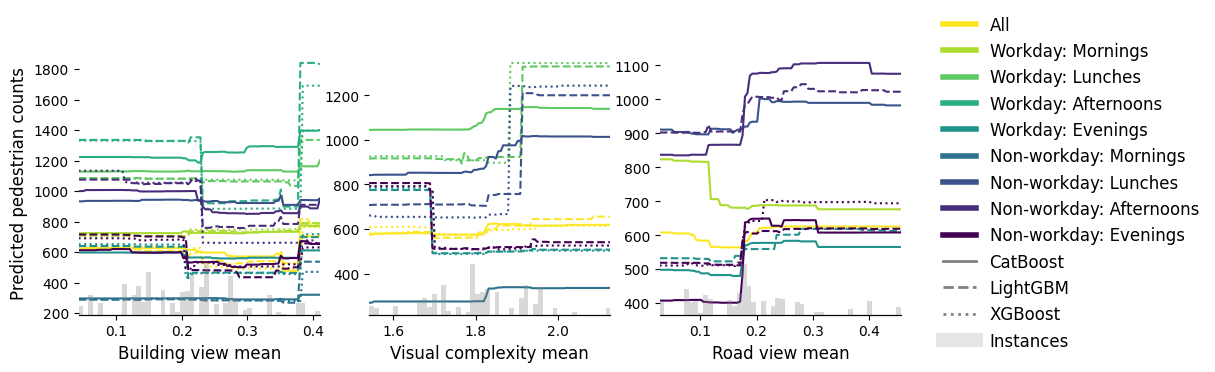

In [84]:
Visual_index = {
    "Visual index": ["Building view mean","Visual complexity mean","Road view mean"]} # ,"Green view mean","Sky view mean"

plot_pdps_with_histogram_from_csv_and_data(selected_features = Visual_index, legend_location =1,legend_row =0)

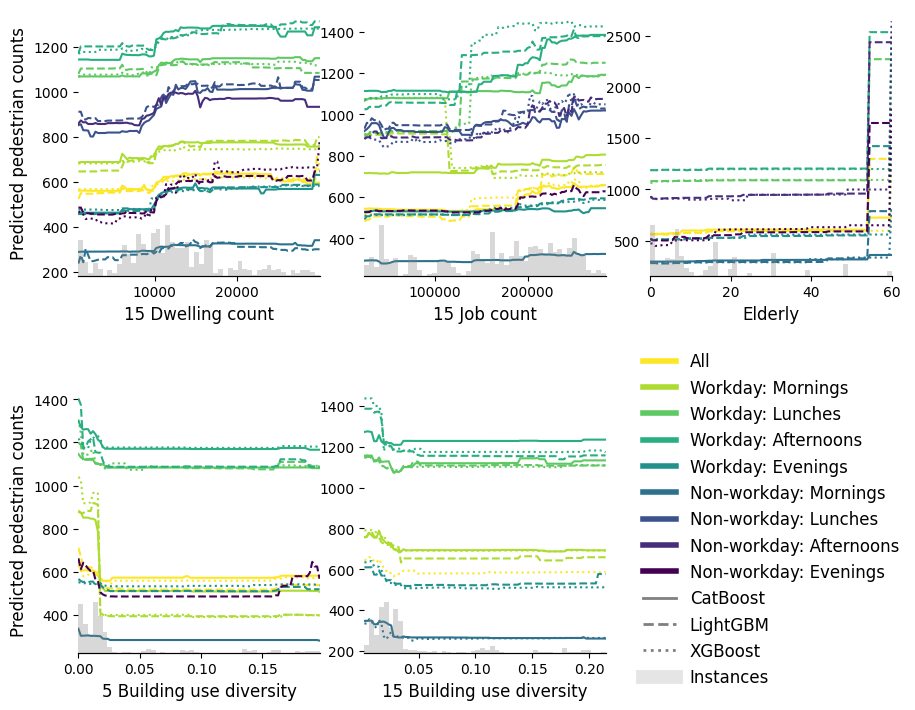

In [82]:
# Updated feature categories
Population = {
    "Population": ["15 Dwelling count", "15 Job count", "Elderly"],#"5 Dwelling count", "5 Job count",
    "Urban use diversity":["5 Building use diversity","15 Building use diversity"]
}
plot_pdps_with_histogram_from_csv_and_data(selected_features = Population, legend_location =0,legend_row =1)

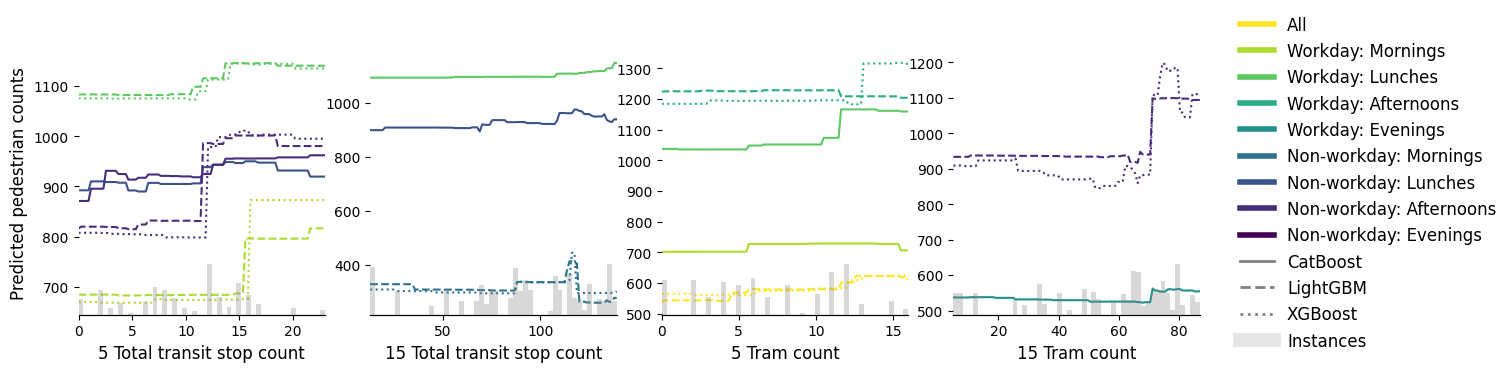

In [88]:
# Updated feature categories
Transport = {
    "Public transport":["5 Total transit stop count","15 Total transit stop count",
                        # "5 Bus count","15 Bus count",
                        "5 Tram count","15 Tram count"]#,"15 Train count","5 Train count"
}
plot_pdps_with_histogram_from_csv_and_data(selected_features = Transport, legend_location =1,legend_row =0)

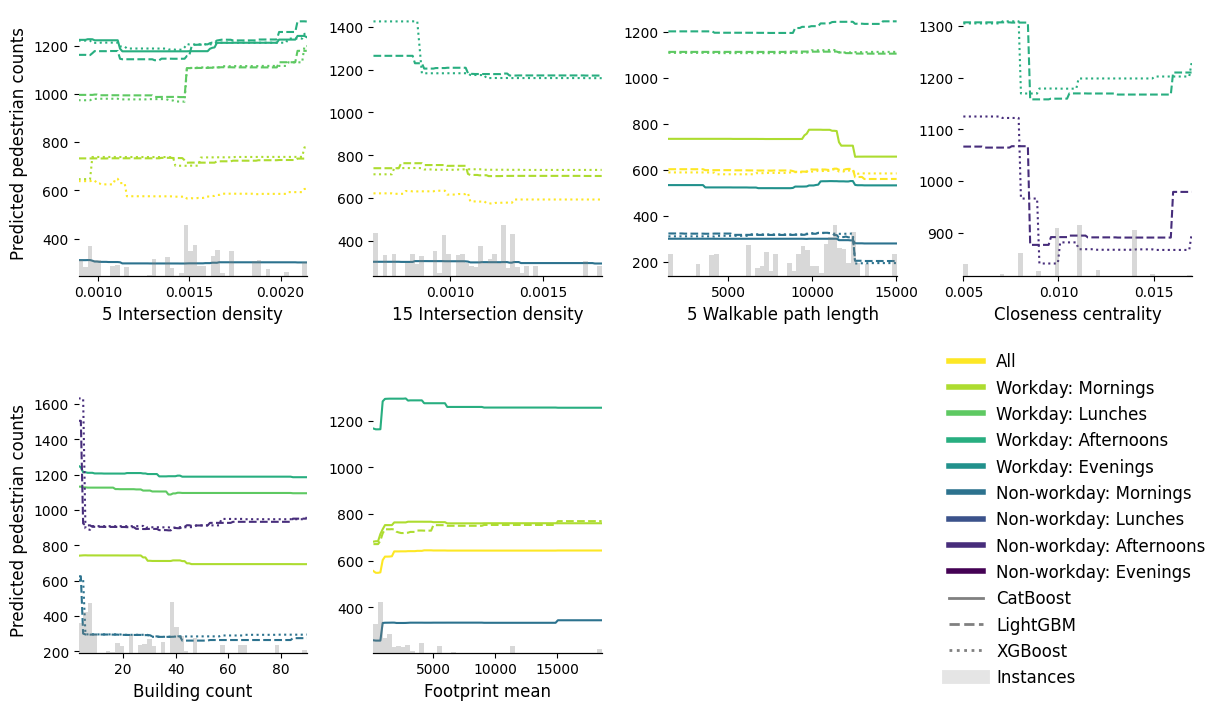

In [29]:
# Updated feature categories
buildings_n_networks = {
    "network":[ "5 Intersection density", "15 Intersection density",
        "5 Walkable path length", #"15 Walkable path length", "5 Edge length avg",
                        "Closeness centrality"], #"15 Edge length avg","Between centrality","15 Intersection density","Closeness centrality"
    "building":["Building count","Footprint mean"]
}
plot_pdps_with_histogram_from_csv_and_data(selected_features = buildings_n_networks, legend_location =0,legend_row =1)

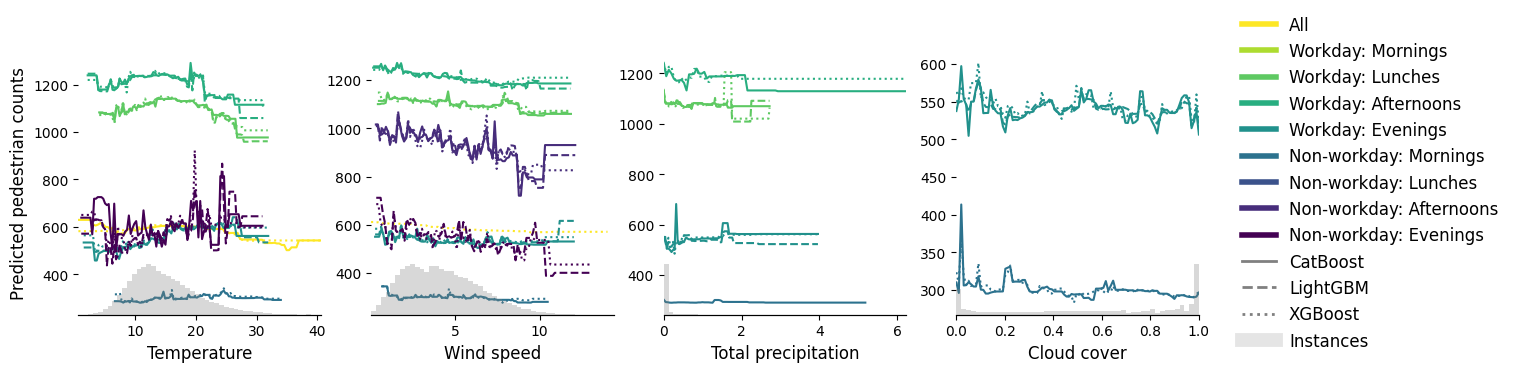

In [98]:
weather = {
    "Weather": ["Temperature", "Wind speed", "Total precipitation","Cloud cover"]
}
plot_pdps_with_histogram_from_csv_and_data(selected_features = weather, legend_location =1,legend_row =0)